In [1]:
print('Notebook Working')

Notebook Working


In [2]:
import pandas as pd

file_path = "../data/combine.csv"

df = pd.read_csv(file_path, nrows=100000)

df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [3]:
# Shows number of rows and columns in dataset
# Example output: (100000, 80) → 100k rows, 80 features
df.shape

(100000, 79)

In [4]:
# Displays the first 5 rows of the dataset
# Helps you visually understand what the data looks like
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
# Shows all column names (features)
# These are the inputs your model will use
df.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [6]:
# Converts column names into a list format (easier to read/copy)
# We use this to find the EXACT label column name
df.columns.tolist()

[' Destination Port',
 ' Flow Duration',
 ' Total Fwd Packets',
 ' Total Backward Packets',
 'Total Length of Fwd Packets',
 ' Total Length of Bwd Packets',
 ' Fwd Packet Length Max',
 ' Fwd Packet Length Min',
 ' Fwd Packet Length Mean',
 ' Fwd Packet Length Std',
 'Bwd Packet Length Max',
 ' Bwd Packet Length Min',
 ' Bwd Packet Length Mean',
 ' Bwd Packet Length Std',
 'Flow Bytes/s',
 ' Flow Packets/s',
 ' Flow IAT Mean',
 ' Flow IAT Std',
 ' Flow IAT Max',
 ' Flow IAT Min',
 'Fwd IAT Total',
 ' Fwd IAT Mean',
 ' Fwd IAT Std',
 ' Fwd IAT Max',
 ' Fwd IAT Min',
 'Bwd IAT Total',
 ' Bwd IAT Mean',
 ' Bwd IAT Std',
 ' Bwd IAT Max',
 ' Bwd IAT Min',
 'Fwd PSH Flags',
 ' Bwd PSH Flags',
 ' Fwd URG Flags',
 ' Bwd URG Flags',
 ' Fwd Header Length',
 ' Bwd Header Length',
 'Fwd Packets/s',
 ' Bwd Packets/s',
 ' Min Packet Length',
 ' Max Packet Length',
 ' Packet Length Mean',
 ' Packet Length Std',
 ' Packet Length Variance',
 'FIN Flag Count',
 ' SYN Flag Count',
 ' RST Flag Count',
 ' P

In [7]:
# Counts how many times each label appears
# This tells us what we're trying to predict (attack types vs benign)
df[' Label'].value_counts()

 Label
DDoS      61194
BENIGN    38806
Name: count, dtype: int64

In [8]:
# Counts missing values in each column
# Helps us see if we need to clean or drop data
df.isnull().sum().sort_values(ascending=False).head(20)

Flow Bytes/s                    3
 Flow Duration                  0
 Destination Port               0
 Total Backward Packets         0
Total Length of Fwd Packets     0
 Total Length of Bwd Packets    0
 Total Fwd Packets              0
 Fwd Packet Length Max          0
 Fwd Packet Length Min          0
 Fwd Packet Length Std          0
 Fwd Packet Length Mean         0
Bwd Packet Length Max           0
 Bwd Packet Length Min          0
 Bwd Packet Length Mean         0
 Bwd Packet Length Std          0
 Flow Packets/s                 0
 Flow IAT Mean                  0
 Flow IAT Std                   0
 Flow IAT Max                   0
 Flow IAT Min                   0
dtype: int64

In [9]:
# Counts duplicate rows in the dataset
# Duplicates can hurt model performance, so we remove them later
df.duplicated().sum()

np.int64(729)

In [10]:
import numpy as np

# Remove duplicate rows
df = df.drop_duplicates()

# Replace infinite values with NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Drop rows with missing values
df = df.dropna()

# Confirm cleaned shape
df.shape

(99268, 79)

In [11]:
# X = all columns except the label
X = df.drop(' Label', axis=1)

# y = what we are trying to predict
y = df[' Label']

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

# Check mapping
list(le.classes_)

['BENIGN', 'DDoS']

In [13]:
#Splitting the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
# Machine learning model + evaluation tools
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [15]:
# Create the Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [16]:
# Train the model using training data
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
# Make predictions using the test set
y_pred = model.predict(X_test)

In [18]:
# Measure overall accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9999496323159062


In [19]:
# Detailed model performance report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7641
           1       1.00      1.00      1.00     12213

    accuracy                           1.00     19854
   macro avg       1.00      1.00      1.00     19854
weighted avg       1.00      1.00      1.00     19854



In [20]:
import joblib

# Save trained model
joblib.dump(model, "../models/random_forest_model.joblib")

# Save label encoder
joblib.dump(le, "../models/label_encoder.joblib")

print("Model and encoder saved successfully")

Model and encoder saved successfully


# Multi-class Random Forest Training

In [21]:
# Check all labels in the dataset
df[' Label'].value_counts()

 Label
DDoS      61191
BENIGN    38077
Name: count, dtype: int64

In [22]:
# Keep only the attack types we want for the project
target_labels = [
    "BENIGN",
    "DDoS",
    "PortScan",
    "FTP-Patator",
    "SSH-Patator",
    "Web Attack – Brute Force",
    "Web Attack – XSS",
    "Web Attack – Sql Injection"
]

df_multi = df[df[' Label'].isin(target_labels)].copy()
df_multi[' Label'].value_counts()

 Label
DDoS      61191
BENIGN    38077
Name: count, dtype: int64

In [23]:
# Group detailed CICIDS labels into project-friendly categories
def map_attack(label):
    if label == "BENIGN":
        return "BENIGN"
    elif label == "DDoS":
        return "DDoS"
    elif label == "PortScan":
        return "Port Scan"
    elif label in ["FTP-Patator", "SSH-Patator"]:
        return "Brute Force"
    elif label in ["Web Attack – Brute Force", "Web Attack – XSS", "Web Attack – Sql Injection"]:
        return "Web Attack"
    else:
        return "Other"

df_multi['Attack_Category'] = df_multi[' Label'].apply(map_attack)

df_multi['Attack_Category'].value_counts()

Attack_Category
DDoS      61191
BENIGN    38077
Name: count, dtype: int64

In [24]:
# Prepare features and labels for multi-class classification
X = df_multi.drop([' Label', 'Attack_Category'], axis=1)
y = df_multi['Attack_Category']

In [25]:
# Encode the multi-class labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

list(le.classes_)

['BENIGN', 'DDoS']

In [26]:
#Splitting the multi-class data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [27]:
# Create and train the Random Forest model for multi-class classification
from sklearn.ensemble import RandomForestClassifier

rf_multi = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_multi.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [28]:
#Evaluate the multi-class model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf_multi.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9998488969477184
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      7616
        DDoS       1.00      1.00      1.00     12238

    accuracy                           1.00     19854
   macro avg       1.00      1.00      1.00     19854
weighted avg       1.00      1.00      1.00     19854

[[ 7616     0]
 [    3 12235]]


In [29]:
# Save the multi-class model and label encoder for future use
import joblib

joblib.dump(rf_multi, "../models/random_forest_multiclass_model.joblib")
joblib.dump(le, "../models/multiclass_label_encoder.joblib")

print("Multi-class model and label encoder saved successfully.")

Multi-class model and label encoder saved successfully.


In [30]:
# Measure overall accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9998488969477184


In [31]:
# Detailed performance report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      7616
        DDoS       1.00      1.00      1.00     12238

    accuracy                           1.00     19854
   macro avg       1.00      1.00      1.00     19854
weighted avg       1.00      1.00      1.00     19854



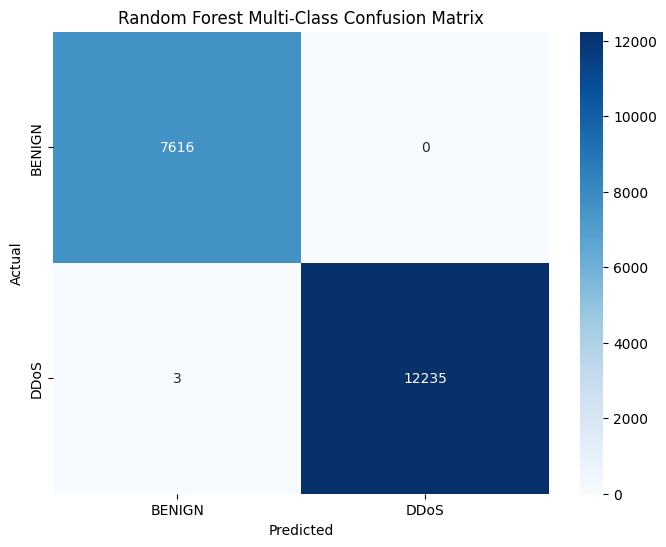

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Multi-Class Confusion Matrix")
plt.show()

Load Multiple CICIDS2017 Attack Files

In [33]:
##Load Multiple CICIDS2017 Attack Files
import pandas as pd

files = [
    "../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "../data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "../data/Tuesday-WorkingHours.pcap_ISCX.csv",
    "../data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"
]

# Combine selected attack datasets
df_multi = pd.concat(
    [pd.read_csv(file) for file in files],
    ignore_index=True
)

print(df_multi.shape)

df_multi[' Label'].value_counts()

(1128487, 79)


 Label
BENIGN                        825515
PortScan                      158930
DDoS                          128027
FTP-Patator                     7938
SSH-Patator                     5897
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64

In [34]:
# Clean combined dataset
import numpy as np

# Remove duplicates
df_multi = df_multi.drop_duplicates()

# Replace infinite values
df_multi = df_multi.replace([np.inf, -np.inf], np.nan)

# Drop missing values
df_multi = df_multi.dropna()

print(df_multi.shape)

(1010076, 79)


In [35]:
# Map detailed CICIDS labels into project attack categories
def map_attack(label):
    if label == "BENIGN":
        return "BENIGN"
    elif label == "DDoS":
        return "DDoS"
    elif label == "PortScan":
        return "Port Scan"
    elif label in ["FTP-Patator", "SSH-Patator"]:
        return "Brute Force"
    elif "Web Attack" in label:
        return "Web Attack"
    else:
        return "Other"

df_multi['Attack_Category'] = df_multi[' Label'].apply(map_attack)

df_multi['Attack_Category'].value_counts()

Attack_Category
BENIGN         780075
DDoS           128014
Port Scan       90694
Brute Force      9150
Web Attack       2143
Name: count, dtype: int64

In [36]:
# Features and target
X = df_multi.drop([' Label', 'Attack_Category'], axis=1)
y = df_multi['Attack_Category']

In [37]:
# Encode the multi-class labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(le.classes_)

['BENIGN' 'Brute Force' 'DDoS' 'Port Scan' 'Web Attack']


In [38]:
#Splitting the multi-class data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [39]:
# Create and train the Random Forest model for multi-class classification
from sklearn.ensemble import RandomForestClassifier

rf_multi = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_multi.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [40]:
# Generate predictions
y_pred = rf_multi.predict(X_test)

In [41]:
# Measure overall accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9998564470140979


In [42]:
# Detailed performance report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    156016
 Brute Force       1.00      1.00      1.00      1830
        DDoS       1.00      1.00      1.00     25603
   Port Scan       1.00      1.00      1.00     18139
  Web Attack       1.00      0.96      0.98       428

    accuracy                           1.00    202016
   macro avg       1.00      0.99      1.00    202016
weighted avg       1.00      1.00      1.00    202016



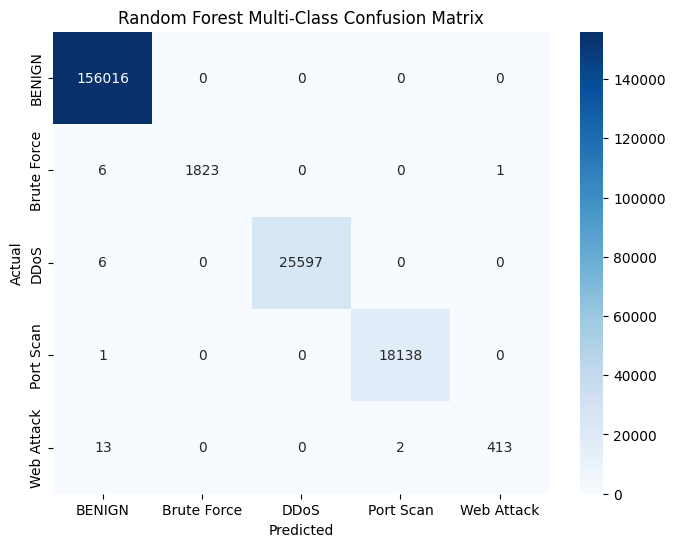

In [43]:
#Multi-class confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Multi-Class Confusion Matrix")

plt.show()

In [44]:
# Save the multi-class model and label encoder for future use
import joblib

joblib.dump(rf_multi, "../models/random_forest_multiclass_model.joblib")
joblib.dump(le, "../models/multiclass_label_encoder.joblib")

print("Multi-class model and encoder saved successfully")

Multi-class model and encoder saved successfully


In [45]:
# =========================
# Logistic Regression Model
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

log_reg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ))
])

log_reg_model.fit(X_train, y_train)

log_reg_pred = log_reg_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_reg_pred))

print(classification_report(
    y_test,
    log_reg_pred,
    target_names=le.classes_
))

c:\Users\talar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression Accuracy: 0.9932827102803738
              precision    recall  f1-score   support

      BENIGN       0.99      1.00      1.00    156016
 Brute Force       0.97      0.96      0.97      1830
        DDoS       1.00      0.98      0.99     25603
   Port Scan       0.98      1.00      0.99     18139
  Web Attack       0.74      0.05      0.09       428

    accuracy                           0.99    202016
   macro avg       0.94      0.80      0.81    202016
weighted avg       0.99      0.99      0.99    202016



In [46]:
# =========================
# XGBoost Model
# =========================

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

print(classification_report(
    y_test,
    xgb_pred,
    target_names=le.classes_
))

XGBoost Accuracy: 0.9999455488674165
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    156016
 Brute Force       1.00      1.00      1.00      1830
        DDoS       1.00      1.00      1.00     25603
   Port Scan       1.00      1.00      1.00     18139
  Web Attack       1.00      0.99      0.99       428

    accuracy                           1.00    202016
   macro avg       1.00      1.00      1.00    202016
weighted avg       1.00      1.00      1.00    202016



In [ ]:
#Model comparison table
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, log_reg_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred, average="weighted"),
        precision_score(y_test, log_reg_pred, average="weighted"),
        precision_score(y_test, xgb_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, log_reg_pred, average="weighted"),
        recall_score(y_test, xgb_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, log_reg_pred, average="weighted"),
        f1_score(y_test, xgb_pred, average="weighted")
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.999856,0.999856,0.999856,0.999856
1,Logistic Regression,0.993283,0.992800,0.993283,0.992379
2,XGBoost,0.999946,0.999945,0.999946,0.999945
